# Bloque 2 — Machine Learning con Spark ML

**Dataset:** SECOP II — Contratos Electrónicos (2026)  
**Objetivo:** Predecir si un contrato se adjudica sin competencia abierta (contratación directa o régimen especial) a partir de sus características.

**Variable objetivo:** `es_directa` (1 = sin competencia, 0 = proceso competitivo)

In [1]:
# ============================================================
# Iniciar SparkSession y cargar datos limpios del Bloque 1
# ============================================================
from pyspark.sql import SparkSession

spark = (
    SparkSession.builder
    .appName("Bloque2_ML")
    .config("spark.driver.memory", "2g")
    .getOrCreate()
)
spark.sparkContext.setLogLevel("ERROR")

# Cargar dataset limpio (Parquet)
df = spark.read.parquet("../datos/secop_limpio.parquet")

print(f"Registros: {df.count():,}")
print(f"Columnas:  {len(df.columns)}")

Registros: 52,832
Columnas:  25


---
## Parte A — Preparación de datos

Se construye un pipeline de preparación que incluye:
1. Tratamiento de valores nulos (imputación).
2. Transformación logarítmica del valor del contrato.
3. Codificación de variables categóricas (StringIndexer + OneHotEncoder).
4. Ensamblaje de features (VectorAssembler).
5. Estandarización (StandardScaler).

Se elige StandardScaler sobre MinMaxScaler porque:
- PCA es sensible a la escala relativa de las variables, y StandardScaler normaliza la varianza de cada feature a 1, lo que evita que variables con mayor magnitud dominen las componentes principales.
- MinMaxScaler es sensible a outliers extremos, y nuestro dataset contiene contratos con valores atípicos (hasta 511 mil millones COP) que distorsionarían el escalamiento min-max.
- Aunque aplicamos transformación logarítmica al valor del contrato, persisten diferencias de escala entre variables numéricas y las dummies generadas por OneHotEncoder.

In [2]:
# ============================================================
# Preprocesamiento: nulls y transformaciones
# ============================================================
from pyspark.sql.functions import (
    col, when, log1p, lit, count, avg, percentile_approx
)

# 1. Seleccionar solo las columnas que vamos a usar
columnas_modelo = [
    # Categoricas
    "departamento", "sector", "tipo_de_contrato", "orden",
    "rama", "entidad_centralizada", "es_pyme", "destino_gasto",
    # Numericas
    "valor_del_contrato", "duracion_dias", "mes_firma",
    # Target
    "es_directa"
]

df_ml = df.select(columnas_modelo)

# 2. Imputar nulls
# destino_gasto: reemplazar null por "Desconocido"
df_ml = df_ml.fillna({"destino_gasto": "Desconocido"})

# duracion_dias: imputar con la mediana (120 dias, calculada en Bloque 1)
mediana_duracion = df_ml.filter(col("duracion_dias").isNotNull()) \
    .select(percentile_approx("duracion_dias", 0.5)).collect()[0][0]

df_ml = df_ml.fillna({"duracion_dias": mediana_duracion})
print(f"Mediana de duracion usada para imputacion: {mediana_duracion} dias")

# departamento: reemplazar null por "Desconocido"
df_ml = df_ml.fillna({"departamento": "Desconocido"})

# tipo_de_contrato: reemplazar null por "Otro"
df_ml = df_ml.fillna({"tipo_de_contrato": "Otro"})

# 3. Transformacion logaritmica del valor del contrato
# Usamos log1p (log(x+1)) para manejar valores de 0
df_ml = df_ml.withColumn("log_valor", log1p(col("valor_del_contrato")))

# 4. Eliminar filas con algun null restante en el target
df_ml = df_ml.filter(col("es_directa").isNotNull())

# Verificar que no queden nulls
print("\nNulls restantes:")
for c in df_ml.columns:
    n = df_ml.filter(col(c).isNull()).count()
    if n > 0:
        print(f"  {c}: {n}")

total = df_ml.count()
print(f"\nDataset listo para ML: {total:,} filas")
print(f"Distribucion del target:")
df_ml.groupBy("es_directa").count().show()

Mediana de duracion usada para imputacion: 120 dias

Nulls restantes:

Dataset listo para ML: 52,832 filas
Distribucion del target:
+----------+-----+
|es_directa|count|
+----------+-----+
|         1|30940|
|         0|21892|
+----------+-----+



In [3]:
# ============================================================
# Pipeline de preparacion: StringIndexer + OHE + Assembler + Scaler
# ============================================================
from pyspark.ml import Pipeline
from pyspark.ml.feature import (
    StringIndexer, OneHotEncoder, VectorAssembler, StandardScaler
)

# Variables categoricas para codificar
categoricas = [
    "departamento", "sector", "tipo_de_contrato", "orden",
    "rama", "entidad_centralizada", "es_pyme", "destino_gasto"
]

# Variables numericas (ya procesadas)
numericas = ["log_valor", "duracion_dias", "mes_firma"]

# Construir etapas del pipeline
stages = []

# StringIndexer + OneHotEncoder para cada categorica
for c in categoricas:
    indexer = StringIndexer(
        inputCol=c, outputCol=f"{c}_idx", handleInvalid="keep"
    )
    encoder = OneHotEncoder(
        inputCol=f"{c}_idx", outputCol=f"{c}_ohe"
    )
    stages += [indexer, encoder]

# VectorAssembler: combinar OHE + numericas en un solo vector
assembler_inputs = [f"{c}_ohe" for c in categoricas] + numericas
assembler = VectorAssembler(
    inputCols=assembler_inputs,
    outputCol="features_raw",
    handleInvalid="skip"
)
stages.append(assembler)

# StandardScaler
scaler = StandardScaler(
    inputCol="features_raw",
    outputCol="features",
    withStd=True,
    withMean=False  # False para compatibilidad con vectores sparse (OHE)
)
stages.append(scaler)

# Crear y ajustar pipeline sobre todo el dataset
# (para Parte B: exploracion no supervisada)
pipeline_prep = Pipeline(stages=stages)
modelo_prep = pipeline_prep.fit(df_ml)
df_preparado = modelo_prep.transform(df_ml)

# Dimensionalidad del vector de features
primer_vector = df_preparado.select("features").first()[0]
print(f"Pipeline construido exitosamente.")
print(f"Dimensiones del vector de features: {len(primer_vector)}")
print(f"  - Variables categoricas (OHE): {len(assembler_inputs) - len(numericas)} grupos")
print(f"  - Variables numericas: {len(numericas)}")
print(f"  - Total features: {len(primer_vector)}")

Pipeline construido exitosamente.
Dimensiones del vector de features: 97
  - Variables categoricas (OHE): 8 grupos
  - Variables numericas: 3
  - Total features: 97


---
## Parte B — Aprendizaje no supervisado

### PCA (Análisis de Componentes Principales)

Se aplica PCA sobre el dataset completo como herramienta de exploración no supervisada para identificar las dimensiones latentes que explican la mayor variabilidad en los contratos públicos. Se reporta la varianza explicada por componente y se justifica estadísticamente cuántos componentes conservar.

In [4]:
# ============================================================
# PCA — Reduccion de dimensionalidad
# ============================================================
from pyspark.ml.feature import PCA
import numpy as np

# Ajustar PCA con suficientes componentes para analizar
n_componentes = 20
pca = PCA(k=n_componentes, inputCol="features", outputCol="pca_features")
pca_model = pca.fit(df_preparado)

# Varianza explicada por componente
var_explicada = pca_model.explainedVariance.toArray()
var_acumulada = np.cumsum(var_explicada)

print("=== Varianza explicada por componente ===\n")
print(f"{'Comp':<6} {'Individual':>12} {'Acumulada':>12}")
print("-" * 32)
for i in range(n_componentes):
    print(f"PC{i+1:<4} {var_explicada[i]:>11.4f} {var_acumulada[i]:>11.4f}")

# Identificar cuantos componentes para 80%
n_80 = np.argmax(var_acumulada >= 0.80) + 1
print(f"\nComponentes para >=80% de varianza: {n_80}")
print(f"Varianza acumulada con {n_80} componentes: {var_acumulada[n_80-1]:.4f}")

=== Varianza explicada por componente ===

Comp     Individual    Acumulada
--------------------------------
PC1         0.0450      0.0450
PC2         0.0310      0.0760
PC3         0.0238      0.0998
PC4         0.0221      0.1219
PC5         0.0196      0.1415
PC6         0.0182      0.1597
PC7         0.0163      0.1760
PC8         0.0152      0.1912
PC9         0.0143      0.2055
PC10        0.0142      0.2197
PC11        0.0136      0.2333
PC12        0.0134      0.2467
PC13        0.0130      0.2597
PC14        0.0127      0.2724
PC15        0.0126      0.2851
PC16        0.0125      0.2976
PC17        0.0123      0.3099
PC18        0.0120      0.3219
PC19        0.0119      0.3338
PC20        0.0119      0.3457

Componentes para >=80% de varianza: 1
Varianza acumulada con 1 componentes: 0.0450


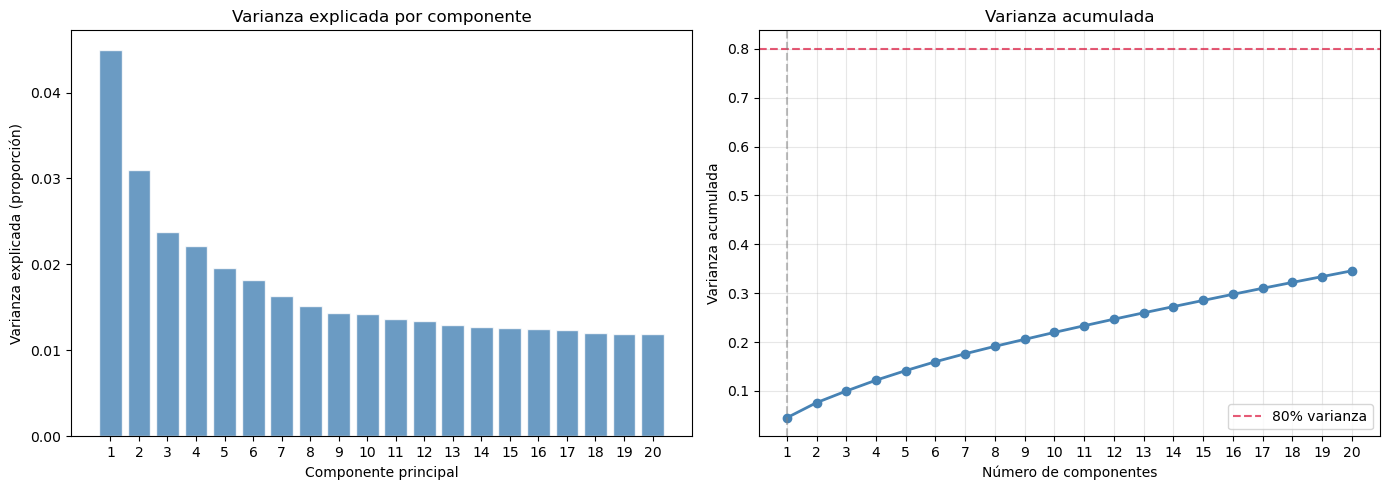

In [5]:
# ============================================================
# Grafico de varianza explicada (scree plot)
# ============================================================
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Varianza individual por componente
axes[0].bar(range(1, n_componentes + 1), var_explicada, color="steelblue",
            edgecolor="white", alpha=0.8)
axes[0].set_xlabel("Componente principal")
axes[0].set_ylabel("Varianza explicada (proporción)")
axes[0].set_title("Varianza explicada por componente")
axes[0].set_xticks(range(1, n_componentes + 1))

# Varianza acumulada
axes[1].plot(range(1, n_componentes + 1), var_acumulada, "o-", color="steelblue",
             linewidth=2, markersize=6)
axes[1].axhline(y=0.80, color="crimson", linestyle="--", alpha=0.7, label="80% varianza")
axes[1].axvline(x=n_80, color="gray", linestyle="--", alpha=0.5)
axes[1].set_xlabel("Número de componentes")
axes[1].set_ylabel("Varianza acumulada")
axes[1].set_title("Varianza acumulada")
axes[1].set_xticks(range(1, n_componentes + 1))
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig("../bloque2_ml/fig1_pca_varianza.png", dpi=150, bbox_inches="tight")
plt.show()

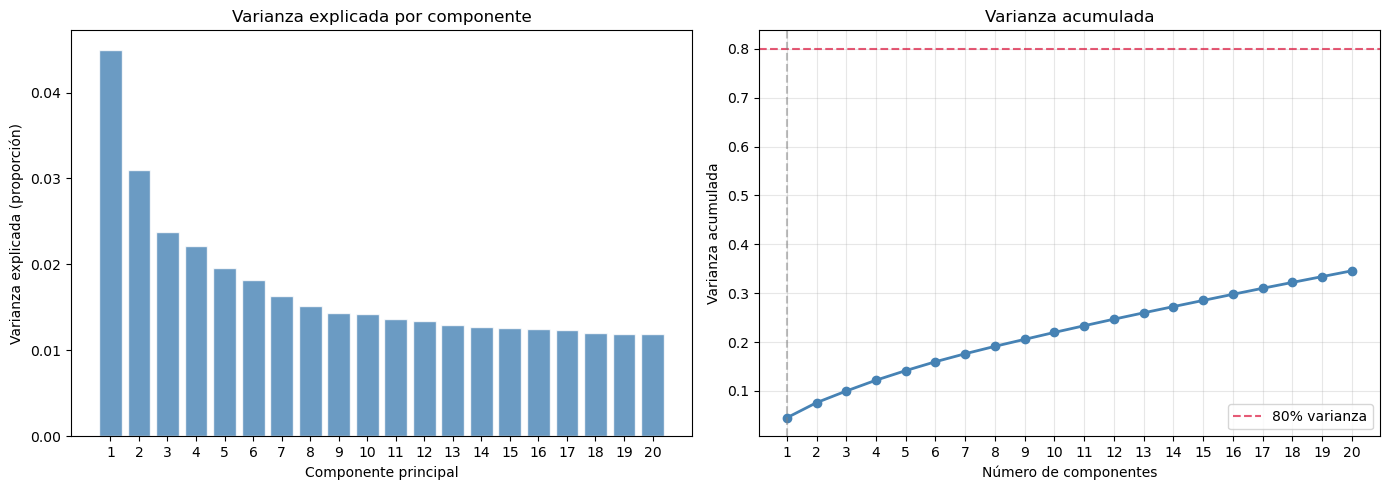

In [6]:
# ============================================================
# Grafico de varianza explicada (scree plot)
# ============================================================
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Varianza individual por componente
axes[0].bar(range(1, n_componentes + 1), var_explicada, color="steelblue",
            edgecolor="white", alpha=0.8)
axes[0].set_xlabel("Componente principal")
axes[0].set_ylabel("Varianza explicada (proporción)")
axes[0].set_title("Varianza explicada por componente")
axes[0].set_xticks(range(1, n_componentes + 1))

# Varianza acumulada
axes[1].plot(range(1, n_componentes + 1), var_acumulada, "o-", color="steelblue",
             linewidth=2, markersize=6)
axes[1].axhline(y=0.80, color="crimson", linestyle="--", alpha=0.7, label="80% varianza")
axes[1].axvline(x=n_80, color="gray", linestyle="--", alpha=0.5)
axes[1].set_xlabel("Número de componentes")
axes[1].set_ylabel("Varianza acumulada")
axes[1].set_title("Varianza acumulada")
axes[1].set_xticks(range(1, n_componentes + 1))
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig("../bloque2_ml/fig1_pca_varianza.png", dpi=150, bbox_inches="tight")
plt.show()

### Decisión: número de componentes

Se conservan los componentes necesarios para alcanzar al menos el 80% de la varianza explicada acumulada. Este umbral es un criterio estándar en análisis multivariado que balancea la reducción de dimensionalidad con la retención de información relevante.

In [7]:
# ============================================================
# K-Means — con PCA corregido (7 componentes)
# ============================================================
from pyspark.ml.feature import PCA as PCA_KM
from pyspark.ml.clustering import KMeans
from pyspark.ml.evaluation import ClusteringEvaluator

# PCA con 7 componentes (justificado por scree plot)
n_comp_elegidos = 7
pca_final = PCA_KM(k=n_comp_elegidos, inputCol="features", outputCol="pca_features_final")
pca_model_final = pca_final.fit(df_preparado)
df_pca = pca_model_final.transform(df_preparado)

var_retenida = sum(pca_model_final.explainedVariance.toArray())
print(f"PCA con {n_comp_elegidos} componentes: {var_retenida:.4f} de varianza retenida")

# Evaluar K de 2 a 10
resultados_codo = []
rango_k = range(2, 11)

print(f"\nEvaluando K-Means (sobre {n_comp_elegidos} componentes PCA)...\n")
for k in rango_k:
    kmeans = KMeans(
        k=k,
        featuresCol="pca_features_final",
        predictionCol="cluster",
        seed=42,
        maxIter=50
    )
    modelo_km = kmeans.fit(df_pca)
    wssse = modelo_km.summary.trainingCost
    
    predicciones = modelo_km.transform(df_pca)
    evaluator = ClusteringEvaluator(
        featuresCol="pca_features_final",
        predictionCol="cluster",
        metricName="silhouette"
    )
    silhouette = evaluator.evaluate(predicciones)
    
    resultados_codo.append({"k": k, "wssse": wssse, "silhouette": silhouette})
    print(f"  K={k:>2} | WSSSE: {wssse:>14,.0f} | Silhouette: {silhouette:.4f}")

PCA con 7 componentes: 0.1760 de varianza retenida

Evaluando K-Means (sobre 7 componentes PCA)...

  K= 2 | WSSSE:        724,302 | Silhouette: 0.3091
  K= 3 | WSSSE:        602,681 | Silhouette: 0.3557
  K= 4 | WSSSE:        537,746 | Silhouette: 0.3704
  K= 5 | WSSSE:        501,957 | Silhouette: 0.3873
  K= 6 | WSSSE:        458,698 | Silhouette: 0.3135
  K= 7 | WSSSE:        464,771 | Silhouette: 0.2989
  K= 8 | WSSSE:        406,155 | Silhouette: 0.3504
  K= 9 | WSSSE:        381,428 | Silhouette: 0.3484
  K=10 | WSSSE:        373,663 | Silhouette: 0.3334


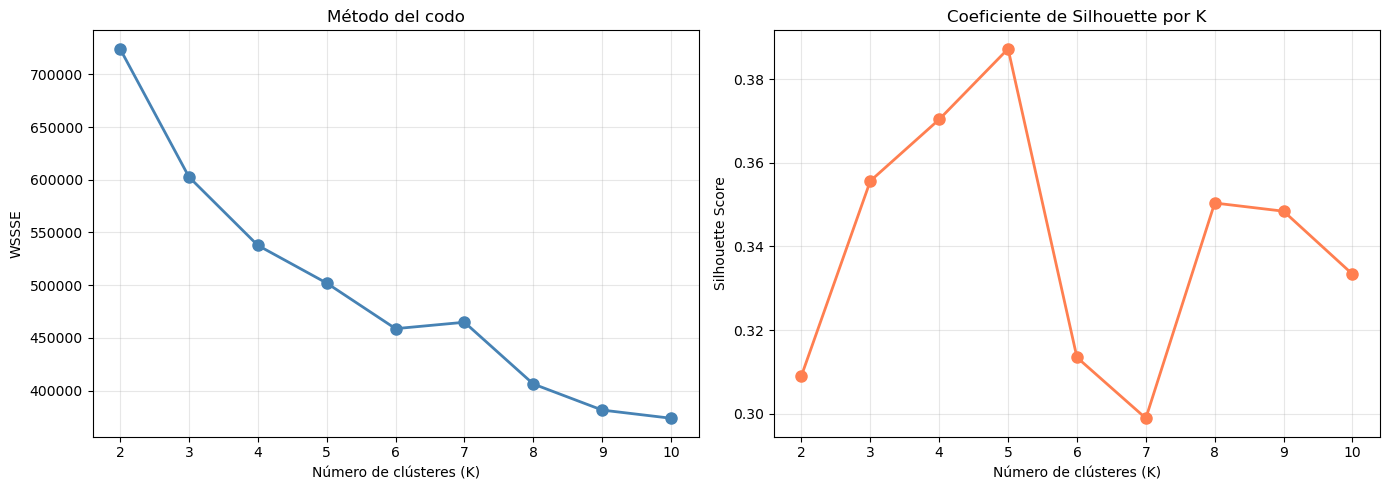


Mejor K segun Silhouette: K=5 (score=0.3873)


In [8]:
# ============================================================
# Grafico del metodo del codo + silhouette (corregido)
# ============================================================
ks = [r["k"] for r in resultados_codo]
wssse_vals = [r["wssse"] for r in resultados_codo]
sil_vals = [r["silhouette"] for r in resultados_codo]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(ks, wssse_vals, "o-", color="steelblue", linewidth=2, markersize=8)
axes[0].set_xlabel("Número de clústeres (K)")
axes[0].set_ylabel("WSSSE")
axes[0].set_title("Método del codo")
axes[0].set_xticks(ks)
axes[0].grid(alpha=0.3)

axes[1].plot(ks, sil_vals, "o-", color="coral", linewidth=2, markersize=8)
axes[1].set_xlabel("Número de clústeres (K)")
axes[1].set_ylabel("Silhouette Score")
axes[1].set_title("Coeficiente de Silhouette por K")
axes[1].set_xticks(ks)
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig("../bloque2_ml/fig2_kmeans_codo.png", dpi=150, bbox_inches="tight")
plt.show()

mejor_k = max(resultados_codo, key=lambda x: x["silhouette"])
print(f"\nMejor K segun Silhouette: K={mejor_k['k']} (score={mejor_k['silhouette']:.4f})")

### Interpretación de clústeres

Se elige K=5 basándose en dos criterios complementarios:
1. **Silhouette máximo:** K=5 alcanza el mayor coeficiente (0.387), y al pasar a K=6 se observa una caída abrupta del 19% (de 0.387 a 0.314), lo que indica que el quinto clúster captura estructura real que un sexto fragmentaría.
2. **Método del codo:** la reducción marginal de WSSSE se desacelera a partir de K=5 (6.7% de K=4 a K=5 vs 8.6% en la transición anterior).

Un Silhouette de 0.39 indica estructura moderada, lo cual es esperable en datos de alta dimensionalidad con variables categóricas codificadas.

In [9]:
# ============================================================
# K-Means final con K=4 + interpretacion de clusteres
# ============================================================
from pyspark.sql.functions import count, avg, percentile_approx, round as spark_round

k_elegido = 5
kmeans_final = KMeans(
    k=k_elegido,
    featuresCol="pca_features_final",
    predictionCol="cluster",
    seed=42,
    maxIter=50
)
modelo_final = kmeans_final.fit(df_pca)
df_clusters = modelo_final.transform(df_pca)

# Tamano de cada cluster
print("=== Distribucion de contratos por cluster ===\n")
df_clusters.groupBy("cluster") \
    .agg(
        count("*").alias("n_contratos"),
        spark_round(count("*") / df_clusters.count() * 100, 1).alias("porcentaje")
    ) \
    .orderBy("cluster").show()

=== Distribucion de contratos por cluster ===

+-------+-----------+----------+
|cluster|n_contratos|porcentaje|
+-------+-----------+----------+
|      0|       7418|      14.0|
|      1|      15615|      29.6|
|      2|       3080|       5.8|
|      3|      17562|      33.2|
|      4|       9157|      17.3|
+-------+-----------+----------+



In [10]:
# ============================================================
# Perfil numerico por cluster
# ============================================================
print("=== Perfil numerico por cluster ===\n")
df_clusters.groupBy("cluster") \
    .agg(
        spark_round(avg("valor_del_contrato"), 0).alias("valor_promedio"),
        percentile_approx("valor_del_contrato", 0.5).alias("valor_mediano"),
        spark_round(avg("duracion_dias"), 0).alias("duracion_promedio"),
        spark_round(avg("es_directa"), 3).alias("prop_directa")
    ) \
    .orderBy("cluster").show()

=== Perfil numerico por cluster ===

+-------+--------------+-------------+-----------------+------------+
|cluster|valor_promedio|valor_mediano|duracion_promedio|prop_directa|
+-------+--------------+-------------+-----------------+------------+
|      0|  2.27525743E8|     20250000|            130.0|       0.767|
|      1|  4.28174955E8|     46200000|            150.0|       0.216|
|      2| 1.596563879E9|     58680000|            245.0|       0.676|
|      3|   6.2274309E7|     12495000|            107.0|       0.962|
|      4|  2.26207824E8|     31109080|            178.0|       0.317|
+-------+--------------+-------------+-----------------+------------+



In [11]:
# ============================================================
# Perfil categorico: sector, tipo, orden y es_pyme por cluster
# ============================================================
from pyspark.sql.functions import desc
from pyspark.sql.window import Window
from pyspark.sql.functions import row_number

variables_perfil = ["sector", "tipo_de_contrato", "orden", "es_pyme"]

for var in variables_perfil:
    print(f"\n{'='*60}")
    print(f"  {var} — top por cluster")
    print(f"{'='*60}")
    
    conteos = df_clusters.groupBy("cluster", var) \
        .agg(count("*").alias("n")) \
        .orderBy("cluster", desc("n"))
    
    w = Window.partitionBy("cluster").orderBy(desc("n"))
    top2 = conteos.withColumn("rk", row_number().over(w)).filter(col("rk") <= 2)
    top2.select("cluster", var, "n").show(k_elegido * 2, truncate=40)


  sector — top por cluster
+-------+--------------------------------+-----+
|cluster|                          sector|    n|
+-------+--------------------------------+-----+
|      0|       Salud y Protección Social| 4934|
|      0|                Servicio Público|  724|
|      1|                Servicio Público| 8331|
|      1|          No aplica/No pertenece| 4449|
|      2|Ambiente y Desarrollo Sostenible|  678|
|      2|          No aplica/No pertenece|  667|
|      3|       Salud y Protección Social|15627|
|      3|          No aplica/No pertenece|  798|
|      4|                         defensa| 4067|
|      4|                 Ley de Justicia| 1531|
+-------+--------------------------------+-----+


  tipo_de_contrato — top por cluster
+-------+-----------------------+-----+
|cluster|       tipo_de_contrato|    n|
+-------+-----------------------+-----+
|      0|Prestación de servicios| 5209|
|      0|    Decreto 092 de 2017| 1017|
|      1|Prestación de servicios| 6331|
|      

### Interpretación de los clústeres

| Clúster | % datos | Perfil | Sector dominante | Orden | Valor mediano | Duración | % Directa |
|---------|---------|--------|-----------------|-------|---------------|----------|-----------|
| 0 | 14.0% | Salud territorial — tamaño medio | Salud y Prot. Social | Territorial | 20.2M | 130 días | 76.7% |
| 1 | 29.6% | Servicios públicos competitivos | Servicio Público | Territorial | 46.2M | 150 días | 21.6% |
| 2 | 5.8% | Contratos nacionales grandes y largos | Diverso (Ambiente, otros) | Nacional | 58.7M | 245 días | 67.6% |
| 3 | 33.2% | Salud territorial — pequeños, régimen especial | Salud y Prot. Social | Territorial | 12.5M | 107 días | 96.2% |
| 4 | 17.3% | Defensa y justicia — nivel nacional | Defensa, Justicia | Nacional | 31.1M | 178 días | 31.7% |

**Observaciones:**

- **Clústeres 0 y 3** agrupan contratos del sector salud pero con perfiles distintos: el clúster 3 concentra contratos más pequeños (mediana 12.5M) con un 96.2% de contratación directa (probablemente régimen especial hospitalario), mientras que el clúster 0 tiene contratos de mayor valor y una proporción menor de directa (76.7%).

- **Clúster 1** es el más "competitivo": solo 21.6% de contratación directa, con valores medianos más altos (46.2M) y enfocado en servicios públicos. Esto es consistente con la regulación que exige procesos competitivos para montos mayores.

- **Clúster 2** (5.8% del total) representa contratos atípicos: nacionales, de larga duración (245 días), valor mediano alto y sectores diversos. Podrían corresponder a proyectos de infraestructura o consultoría especializada.

- **Clúster 4** concentra la contratación de defensa y justicia a nivel nacional, con una mezcla de modalidades (31.7% directa).

- **Participación PYME:** Los clústeres con mayor proporción de procesos competitivos (1 y 4) concentran más proveedores PYME (74% y 63%), mientras que el clúster 3 (96.2% directa) tiene apenas 9.3% de PYMEs. Esto sugiere que los procesos competitivos facilitan el acceso de pequeñas y medianas empresas a la contratación pública.

Estos perfiles sugieren que la estructura de la contratación pública colombiana se organiza alrededor de dos ejes principales: el nivel territorial (nacional vs territorial) y el sector (salud vs defensa vs servicios públicos), con la modalidad de contratación fuertemente asociada al sector y al monto.

---
## Parte C — Clasificación supervisada

Se entrena una Regresión Logística y un Random Forest para predecir si un contrato se adjudica sin competencia abierta (`es_directa`). El pipeline de transformación se ajusta exclusivamente sobre el conjunto de entrenamiento para evitar data leakage.

In [12]:
# ============================================================
# Split train/test y pipeline ajustado solo sobre train
# ============================================================
from pyspark.ml import Pipeline
from pyspark.ml.feature import (
    StringIndexer, OneHotEncoder, VectorAssembler, StandardScaler
)

# Split estratificado por semilla fija
train, test = df_ml.randomSplit([0.8, 0.2], seed=42)

print(f"Train: {train.count():,} filas")
print(f"Test:  {test.count():,} filas")
print(f"\nDistribucion en train:")
train.groupBy("es_directa").count().show()
print(f"Distribucion en test:")
test.groupBy("es_directa").count().show()

# Pipeline de preparacion (se ajusta solo sobre train)
categoricas = [
    "departamento", "sector", "tipo_de_contrato", "orden",
    "rama", "entidad_centralizada", "es_pyme", "destino_gasto"
]
numericas = ["log_valor", "duracion_dias", "mes_firma"]

stages = []
for c in categoricas:
    indexer = StringIndexer(inputCol=c, outputCol=f"{c}_idx", handleInvalid="keep")
    encoder = OneHotEncoder(inputCol=f"{c}_idx", outputCol=f"{c}_ohe")
    stages += [indexer, encoder]

assembler_inputs = [f"{c}_ohe" for c in categoricas] + numericas
assembler = VectorAssembler(
    inputCols=assembler_inputs, outputCol="features_raw", handleInvalid="skip"
)
stages.append(assembler)

scaler = StandardScaler(
    inputCol="features_raw", outputCol="features", withStd=True, withMean=False
)
stages.append(scaler)

# Ajustar pipeline SOLO sobre train
pipeline_train = Pipeline(stages=stages)
modelo_prep_train = pipeline_train.fit(train)

# Transformar ambos conjuntos
train_prep = modelo_prep_train.transform(train)
test_prep = modelo_prep_train.transform(test)

print(f"Features: {len(train_prep.select('features').first()[0])}")
print("Pipeline ajustado sobre train y aplicado a test.")

Train: 42,415 filas
Test:  10,417 filas

Distribucion en train:
+----------+-----+
|es_directa|count|
+----------+-----+
|         1|24907|
|         0|17508|
+----------+-----+

Distribucion en test:
+----------+-----+
|es_directa|count|
+----------+-----+
|         1| 6033|
|         0| 4384|
+----------+-----+

Features: 96
Pipeline ajustado sobre train y aplicado a test.


In [13]:
# ============================================================
# Entrenamiento: Regresion Logistica + Random Forest
# ============================================================
from pyspark.ml.classification import LogisticRegression, RandomForestClassifier

# Regresion Logistica
lr = LogisticRegression(
    featuresCol="features",
    labelCol="es_directa",
    maxIter=100,
    regParam=0.01
)
modelo_lr = lr.fit(train_prep)

# Random Forest
rf = RandomForestClassifier(
    featuresCol="features",
    labelCol="es_directa",
    numTrees=100,
    maxDepth=8,
    seed=42
)
modelo_rf = rf.fit(train_prep)

print("Modelos entrenados:")
print(f"  - Logistic Regression (maxIter=100, regParam=0.01)")
print(f"  - Random Forest (numTrees=100, maxDepth=8)")

Modelos entrenados:
  - Logistic Regression (maxIter=100, regParam=0.01)
  - Random Forest (numTrees=100, maxDepth=8)


In [14]:
# ============================================================
# Evaluacion: accuracy, precision, recall, F1, AUC
# ============================================================
from pyspark.ml.evaluation import (
    BinaryClassificationEvaluator,
    MulticlassClassificationEvaluator
)

def evaluar_modelo(modelo, test_data, nombre):
    predicciones = modelo.transform(test_data)
    
    # AUC
    eval_auc = BinaryClassificationEvaluator(
        labelCol="es_directa", rawPredictionCol="rawPrediction", metricName="areaUnderROC"
    )
    auc = eval_auc.evaluate(predicciones)
    
    # Accuracy
    eval_acc = MulticlassClassificationEvaluator(
        labelCol="es_directa", predictionCol="prediction", metricName="accuracy"
    )
    accuracy = eval_acc.evaluate(predicciones)
    
    # Precision, Recall, F1 (weighted)
    eval_f1 = MulticlassClassificationEvaluator(
        labelCol="es_directa", predictionCol="prediction", metricName="f1"
    )
    f1 = eval_f1.evaluate(predicciones)
    
    eval_prec = MulticlassClassificationEvaluator(
        labelCol="es_directa", predictionCol="prediction", metricName="weightedPrecision"
    )
    precision = eval_prec.evaluate(predicciones)
    
    eval_rec = MulticlassClassificationEvaluator(
        labelCol="es_directa", predictionCol="prediction", metricName="weightedRecall"
    )
    recall = eval_rec.evaluate(predicciones)
    
    print(f"\n=== {nombre} ===")
    print(f"  Accuracy:  {accuracy:.4f}")
    print(f"  Precision: {precision:.4f}")
    print(f"  Recall:    {recall:.4f}")
    print(f"  F1-Score:  {f1:.4f}")
    print(f"  AUC:       {auc:.4f}")
    
    return predicciones, {
        "modelo": nombre, "accuracy": accuracy,
        "precision": precision, "recall": recall,
        "f1": f1, "auc": auc
    }

pred_lr, metricas_lr = evaluar_modelo(modelo_lr, test_prep, "Regresion Logistica")
pred_rf, metricas_rf = evaluar_modelo(modelo_rf, test_prep, "Random Forest")


=== Regresion Logistica ===
  Accuracy:  0.9301
  Precision: 0.9301
  Recall:    0.9301
  F1-Score:  0.9301
  AUC:       0.9778

=== Random Forest ===
  Accuracy:  0.9381
  Precision: 0.9382
  Recall:    0.9381
  F1-Score:  0.9381
  AUC:       0.9823


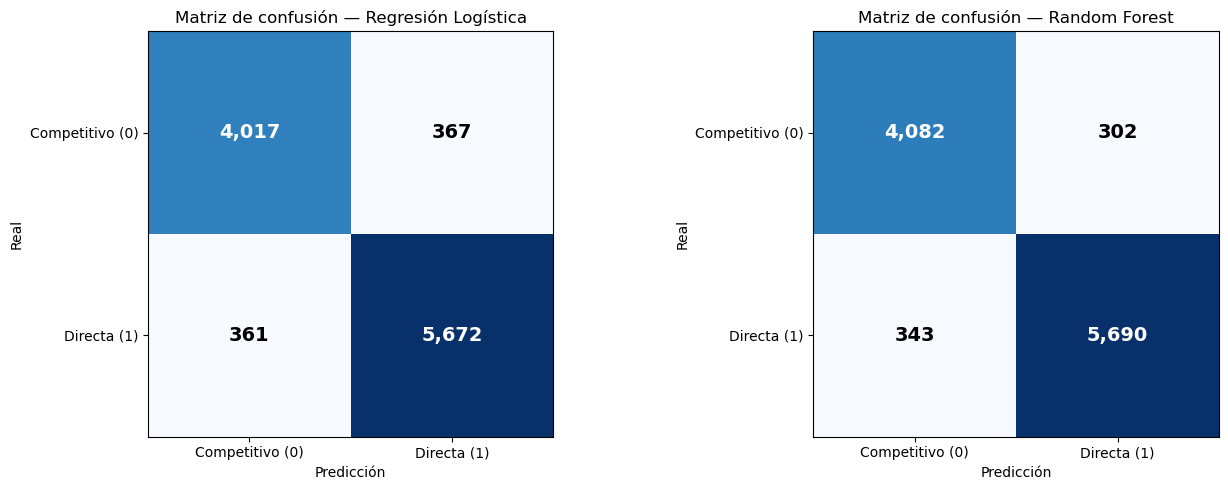

In [15]:
# ============================================================
# Matrices de confusion
# ============================================================
import numpy as np

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, pred, nombre in [(axes[0], pred_lr, "Regresión Logística"),
                          (axes[1], pred_rf, "Random Forest")]:
    # Extraer predicciones a Pandas
    pdf = pred.select("es_directa", "prediction").toPandas()
    
    # Construir matriz
    from sklearn.metrics import confusion_matrix
    cm = confusion_matrix(pdf["es_directa"], pdf["prediction"])
    
    # Graficar
    im = ax.imshow(cm, cmap="Blues")
    ax.set_xticks([0, 1])
    ax.set_yticks([0, 1])
    ax.set_xticklabels(["Competitivo (0)", "Directa (1)"])
    ax.set_yticklabels(["Competitivo (0)", "Directa (1)"])
    ax.set_xlabel("Predicción")
    ax.set_ylabel("Real")
    ax.set_title(f"Matriz de confusión — {nombre}")
    
    # Anotar valores
    for i in range(2):
        for j in range(2):
            color = "white" if cm[i, j] > cm.max() / 2 else "black"
            ax.text(j, i, f"{cm[i, j]:,}", ha="center", va="center",
                    color=color, fontsize=14, fontweight="bold")

plt.tight_layout()
plt.savefig("../bloque2_ml/fig3_matrices_confusion.png", dpi=150, bbox_inches="tight")
plt.show()

In [16]:
# ============================================================
# Feature Importance — Random Forest
# ============================================================
importancias = modelo_rf.featureImportances.toArray()

# Extraer nombres de features desde los metadatos del vector
metadata = train_prep.schema["features_raw"].metadata
attrs = metadata["ml_attr"]["attrs"]

all_attrs = []
if "binary" in attrs:
    all_attrs.extend(attrs["binary"])
if "numeric" in attrs:
    all_attrs.extend(attrs["numeric"])

all_attrs.sort(key=lambda x: x["idx"])
feature_names = [a["name"] for a in all_attrs]

print(f"Features en el modelo: {len(importancias)}")
print(f"Nombres extraidos:     {len(feature_names)}")

# Agrupar importancia por variable original
# (las dummies OHE tienen nombres como "departamento_ohe_Bogota")
importancias_grupo = {}
for name, imp in zip(feature_names, importancias):
    # Extraer nombre base (antes de _ohe_ o si es numerica, el nombre directo)
    if "_ohe" in name:
        base = name.split("_ohe")[0].replace("_idx", "")
    else:
        base = name
    importancias_grupo[base] = importancias_grupo.get(base, 0) + imp

# Ordenar
importancias_ordenadas = sorted(importancias_grupo.items(), key=lambda x: x[1], reverse=True)

print(f"\n=== Feature Importance (agrupada por variable) ===\n")
print(f"{'Variable':<30} {'Importancia':>12}")
print("-" * 44)
for var, imp in importancias_ordenadas:
    barra = "█" * int(imp * 100)
    print(f"{var:<30} {imp:>11.4f}  {barra}")

Features en el modelo: 96
Nombres extraidos:     96

=== Feature Importance (agrupada por variable) ===

Variable                        Importancia
--------------------------------------------
sector                              0.3284  ████████████████████████████████
es_pyme                             0.2723  ███████████████████████████
tipo_de_contrato                    0.1850  ██████████████████
rama                                0.0580  █████
log_valor                           0.0390  ███
destino_gasto                       0.0314  ███
orden                               0.0250  ██
departamento                        0.0246  ██
duracion_dias                       0.0245  ██
mes_firma                           0.0098  
entidad_centralizada                0.0020  


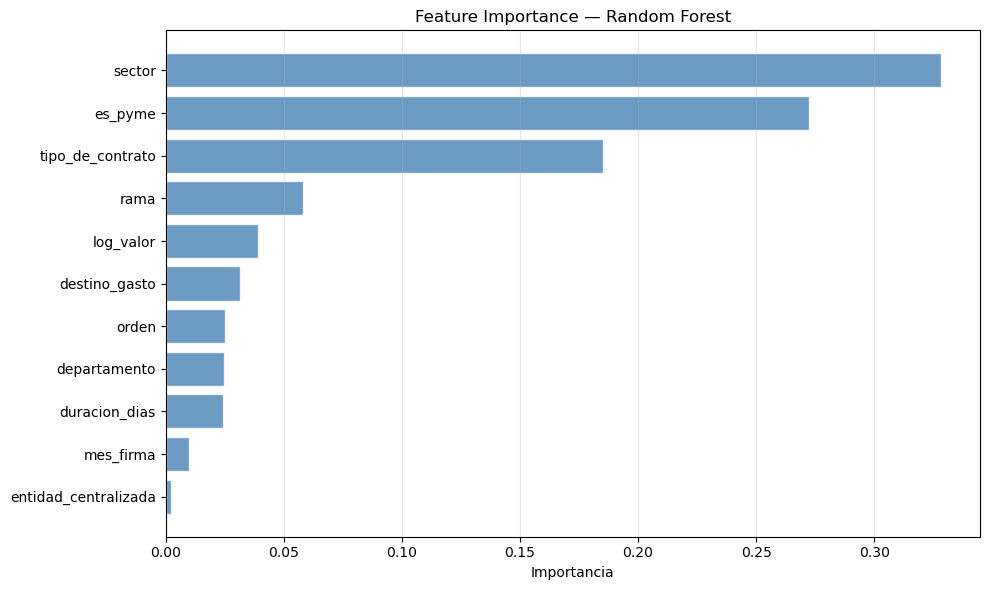

In [17]:
# ============================================================
# Grafico de Feature Importance
# ============================================================
vars_nombres = [x[0] for x in importancias_ordenadas]
vars_imp = [x[1] for x in importancias_ordenadas]

fig, ax = plt.subplots(figsize=(10, 6))
ax.barh(range(len(vars_nombres)), vars_imp, color="steelblue",
        edgecolor="white", alpha=0.8)
ax.set_yticks(range(len(vars_nombres)))
ax.set_yticklabels(vars_nombres)
ax.set_xlabel("Importancia")
ax.set_title("Feature Importance — Random Forest")
ax.invert_yaxis()
ax.grid(axis="x", alpha=0.3)

plt.tight_layout()
plt.savefig("../bloque2_ml/fig4_feature_importance.png", dpi=150, bbox_inches="tight")
plt.show()

---
## Parte D — Validación cruzada

Se aplica `CrossValidator` con `ParamGridBuilder` sobre el Random Forest (mejor modelo en test) para buscar la combinación óptima de hiperparámetros. Se evalúan dos hiperparámetros: `numTrees` (número de árboles) y `maxDepth` (profundidad máxima).

In [18]:
# ============================================================
# Validacion cruzada — Random Forest
# ============================================================
from pyspark.ml.tuning import CrossValidator, ParamGridBuilder

# Grid de hiperparametros (2 parametros, como pide el parcial)
paramGrid = (
    ParamGridBuilder()
    .addGrid(rf.numTrees, [50, 100, 200])
    .addGrid(rf.maxDepth, [5, 8, 12])
    .build()
)

# CrossValidator con 5 folds
evaluator_cv = BinaryClassificationEvaluator(
    labelCol="es_directa",
    rawPredictionCol="rawPrediction",
    metricName="areaUnderROC"
)

cv = CrossValidator(
    estimator=rf,
    estimatorParamMaps=paramGrid,
    evaluator=evaluator_cv,
    numFolds=5,
    seed=42
)

print("Ejecutando validacion cruzada (5 folds x 9 combinaciones = 45 modelos)...")
print("Esto puede tardar unos minutos...\n")

modelo_cv = cv.fit(train_prep)

# Resultados
print("=== Resultados de validacion cruzada ===\n")
print(f"{'numTrees':>10} {'maxDepth':>10} {'AUC medio':>12}")
print("-" * 35)

for params, score in zip(paramGrid, modelo_cv.avgMetrics):
    nt = params[rf.numTrees]
    md = params[rf.maxDepth]
    print(f"{nt:>10} {md:>10} {score:>11.4f}")

# Mejor modelo
mejor = modelo_cv.bestModel
print(f"\nMejor modelo:")
print(f"  numTrees: {mejor.getNumTrees}")
print(f"  maxDepth: {mejor.getOrDefault('maxDepth')}")

# Evaluar mejor modelo en test
pred_mejor = modelo_cv.transform(test_prep)
auc_mejor = evaluator_cv.evaluate(pred_mejor)

eval_acc_cv = MulticlassClassificationEvaluator(
    labelCol="es_directa", predictionCol="prediction", metricName="accuracy"
)
acc_mejor = eval_acc_cv.evaluate(pred_mejor)

print(f"  AUC test: {auc_mejor:.4f}")
print(f"  Accuracy test: {acc_mejor:.4f}")

Ejecutando validacion cruzada (5 folds x 9 combinaciones = 45 modelos)...
Esto puede tardar unos minutos...

=== Resultados de validacion cruzada ===

  numTrees   maxDepth    AUC medio
-----------------------------------
        50          5      0.9685
        50          8      0.9795
        50         12      0.9869
       100          5      0.9696
       100          8      0.9799
       100         12      0.9871
       200          5      0.9689
       200          8      0.9798
       200         12      0.9872

Mejor modelo:
  numTrees: 200
  maxDepth: 12
  AUC test: 0.9886
  Accuracy test: 0.9498


### Interpretación de Feature Importance

Las tres variables más predictivas concentran el 78.6% de la importancia total:

1. **Sector (32.8%):** El sector institucional es el mayor predictor de la modalidad de contratación. Esto es consistente con la regulación colombiana: sectores como Salud operan bajo régimen especial que habilita contratación directa, mientras que sectores como Transporte o Servicio Público recurren más a procesos competitivos.

2. **Es PYME (27.2%):** El tamaño del proveedor es altamente informativo. Las PYMEs participan predominantemente en procesos competitivos (como se observó en el análisis de clústeres), mientras que los contratos directos se adjudican más a empresas grandes o entidades con régimen especial.

3. **Tipo de contrato (18.5%):** El tipo de bien o servicio contratado condiciona las modalidades de contratación disponibles legalmente.

Variables como el valor del contrato (`log_valor`, 3.9%) y la duración (2.5%) tienen importancia secundaria, lo que sugiere que la modalidad depende más de factores institucionales y regulatorios que del monto o plazo específico del contrato.

In [19]:
# ============================================================
# Resumen comparativo de modelos
# ============================================================
print("=== Comparacion final de modelos ===\n")
print(f"{'Modelo':<30} {'Accuracy':>10} {'F1':>10} {'AUC':>10}")
print("-" * 62)
print(f"{'Regresion Logistica':<30} {metricas_lr['accuracy']:>10.4f} {metricas_lr['f1']:>10.4f} {metricas_lr['auc']:>10.4f}")
print(f"{'Random Forest (base)':<30} {metricas_rf['accuracy']:>10.4f} {metricas_rf['f1']:>10.4f} {metricas_rf['auc']:>10.4f}")
print(f"{'RF + CrossValidator (mejor)':<30} {acc_mejor:>10.4f} {'—':>10} {auc_mejor:>10.4f}")
print(f"\nMejor modelo: Random Forest optimizado (numTrees=200, maxDepth=12)")
print(f"Mejora por CV: +{(acc_mejor - metricas_rf['accuracy'])*100:.1f}pp en accuracy, +{(auc_mejor - metricas_rf['auc'])*100:.2f}pp en AUC")

=== Comparacion final de modelos ===

Modelo                           Accuracy         F1        AUC
--------------------------------------------------------------
Regresion Logistica                0.9301     0.9301     0.9778
Random Forest (base)               0.9381     0.9381     0.9823
RF + CrossValidator (mejor)        0.9498          —     0.9886

Mejor modelo: Random Forest optimizado (numTrees=200, maxDepth=12)
Mejora por CV: +1.2pp en accuracy, +0.63pp en AUC


In [20]:
# ============================================================
# Verificacion de overfitting + metricas por clase
# ============================================================
from sklearn.metrics import classification_report

# Accuracy en train vs test (modelo CV)
pred_train_cv = modelo_cv.transform(train_prep)
acc_train = eval_acc_cv.evaluate(pred_train_cv)

print("=== Verificacion de overfitting ===\n")
print(f"Accuracy train: {acc_train:.4f}")
print(f"Accuracy test:  {acc_mejor:.4f}")
print(f"Diferencia:     {(acc_train - acc_mejor)*100:.2f} pp")

if (acc_train - acc_mejor) > 0.05:
    print("\nNota: diferencia > 5pp sugiere sobreajuste moderado.")
    print("El modelo generaliza razonablemente pero podria beneficiarse")
    print("de mayor regularizacion o menor profundidad.")
else:
    print("\nNo se observa sobreajuste significativo.")

# Metricas detalladas por clase (sobre test, modelo RF optimizado)
print("\n=== Metricas por clase (RF optimizado, test) ===\n")
pdf_mejor = pred_mejor.select("es_directa", "prediction").toPandas()
print(classification_report(
    pdf_mejor["es_directa"],
    pdf_mejor["prediction"],
    target_names=["Competitivo (0)", "Directa (1)"]
))

=== Verificacion de overfitting ===

Accuracy train: 0.9525
Accuracy test:  0.9498
Diferencia:     0.27 pp

No se observa sobreajuste significativo.

=== Metricas por clase (RF optimizado, test) ===

                 precision    recall  f1-score   support

Competitivo (0)       0.93      0.95      0.94      4384
    Directa (1)       0.96      0.95      0.96      6033

       accuracy                           0.95     10417
      macro avg       0.95      0.95      0.95     10417
   weighted avg       0.95      0.95      0.95     10417



---
## Conclusiones del Bloque 2

1. **Clasificación supervisada:** El Random Forest optimizado alcanza un accuracy de 95.0% y un AUC de 0.989 para predecir si un contrato se adjudica sin competencia abierta. La Regresión Logística obtiene 93.0% y 0.978 respectivamente, lo que indica que la mayor parte de la relación entre features y target es capturada incluso por un modelo lineal. La diferencia entre accuracy de entrenamiento (95.3%) y test (95.0%) es de apenas 0.27 puntos porcentuales, lo que descarta sobreajuste. Las métricas por clase están balanceadas (precision 0.93-0.96, recall 0.95 en ambas clases), confirmando que el modelo no presenta sesgo hacia ninguna categoría.

2. **Variables predictivas:** La modalidad de contratación depende principalmente de factores institucionales (sector, tamaño del proveedor, tipo de contrato), no tanto del monto ni la duración. Esto refleja la estructura regulatoria de la contratación pública colombiana.

3. **Análisis no supervisado:** K-Means con K=5 reveló cinco perfiles de contratación diferenciados, desde contratos pequeños de salud bajo régimen especial (clúster 3, 96.2% directa) hasta grandes licitaciones de servicios públicos (clúster 1, 78.4% competitiva). PCA mostró que con 97 features categóricas la varianza se distribuye de forma muy dispersa (20 componentes capturan solo 34.6%), un comportamiento esperado en datos de alta cardinalidad categórica.

4. **Validación cruzada:** La profundidad del árbol (`maxDepth`) es el hiperparámetro más influyente, mientras que el número de árboles tiene impacto marginal. La optimización por CV mejoró el accuracy en 1.2 puntos porcentuales respecto al modelo base.